# Bepaling van soortelijke warmte van water


# Introductie

Water heeft een enorme buffercapaciteit: je moet veel energie toevoegen om de temperatuur van water een graad te verwarmen. In dit practicum gaan we de soortelijke warmte van water bepalen door een bekende hoeveelheid water te verwarmen met een bekende hoeveelheid energie, en de temperatuurstijging te meten.

# Theorie

Geef hier de natuurkundige achtergrond van het onderwerp. 

# Methode en materialen

## Ontwerp
Een waterbad met bekende massa aan water wordt verwarmd met een elektrisch verwarmingselement dat een bekende hoeveelheid energie levert.
De temperatuur van het water wordt gemeten met een temperatuursensor.
Door de temperatuurstijging als functie van de tijd te meten kan de soortelijke warmte van water worden berekend.


## Materialen
Hieronder staat de lijst van benodigde materialen bij deze proef:
- Maatbeker
- Weegschaal
- Water
- Elektrisch verwarmingselement ($10 \mathrm{\Omega}$, $10 \mathrm{W}$)
- Voedingsbron 
- Thermometer of temperatuursensor
- Stopwatch of timer

```{figure} figures/cwater_setup.jpg
:width: 70%

Een schematische weergave van de opstelling
```

## Procedure
```{exercise}
1. Beschrijf de procedure die nodig is om de soortelijke warmte van water te bepalen.

1.1: Weeg de massa van de lege meetbeker, vul de meetbeker met 250 of 500 ml (noteer), weeg de meetbeker en bep. massa van het water.
1.2: Plaats warmingselement in het water (uit, niet tegen wand), plaats thermometer in het water, wacht tot het stabiliseerd, en bepaal T_0 (op tijdstip t=0)
1.3: Stel de spanning in zodat we het vermogen weten; schakel de voeding in en start de stopwatch.
1.4: Noteer elke 30 seconden de temperatuur en de tijd op de stopwatch. Tijd kolomn 1, seconden. Temperatuur kolomn 2, graden celcius.
1.5: Noteer meetonzekerheden van het experiment.
1.6: Bepaal op basis van de gevonde data de soortelijke warmte van het water.

2. Geef jouw beschrijving van de procedure aan een ander team, zij verzamelen voor jou de data op basis van de gegevens.
3. Voer het experiment van een ander team uit op basis van hun beschrijving.
4. Analyseer de data die het andere groepje voor jou heeft verzameld.
```


## Veiligheid
We maken gebruik van een $10 \mathrm{\Omega}$, $10 \mathrm{W}$ weerstand.
Deze wordt snel heet.
De bronspanning mag dan ook alleen aan wanneer de weerstand in het water zit.
Raak de weerstand niet aan tijdens het experiment.
Omdat de weerstand in het water zit, kunnen we wel het elektrisch vermogen hoger zetten zonder dat de weerstand oververhit raakt.
Het maximaal vermogen mag $40 \mathrm{W}$ zijn.
Daarbij moet de roerder wel aanstaan om de warmte goed te verdelen.

## Data analyse
Geef kort de data-analysemethode weer.

# Resultaten


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [11]:
# metingen gedaan op basis van stappenplan van het andere team
#m_maatbeker = 0.2766 #kg
#m_totaal = 0.7437 #
#m_water = m_totaal-m_maatbeker
#t = np.array([0,20,40,60,80,100,120,140,160,180,200,220,240,260,280,300,320,340,360,380,400,420])
#T = np.array([20.6,20.7,20.9,21.1,21.3,21.5,21.8,22.0,22.3,22.6,22.9,23.2,23.5,23.7,24.0,24.2,24.4,24.7,24.9,25.2,25.4,25.6])

In [90]:
# metingen door het andere team gedaan op basis van ons stappenplan
data = np.loadtxt(r"Data moene water warm.csv",delimiter=',',skiprows=1) #data inladen
t = data[:,0]
T = data[:,1]+273.15

#constante
m_beker = 0.2766 #kg
c_beker = 840 #J/KgK
m_tot = 0.5266 #kg
m_water = m_tot-m_beker
P = 30  #Watt

delta_t = t[20] - t[1]
delta_T = T[20] - T[1]


cm_tot = (P*delta_t)/delta_T #warmtecapaciteit van het totalen systeem berekenen
c_water = (cm_tot-m_beker*c_beker)/m_water #warmtecapaciteit van alleen het water berekenen

print(f'Soortelijke warmte van water: {c_water:.0f} J/kgK' )

Soortelijke warmte van water: 4292 J/kgK


In [89]:
def func(t,p,c,T_s):
    return (p*t)/(c*m_tot) + T_s

var, cov = curve_fit(func,t[1:],T[1:],p0=(P,2500,300),bounds=([0,2200,280],[30,2800,320]))

c_water = (var[1]*m_tot-m_beker*c_beker)/m_water

t_test = np.linspace(min(t),max(t),1000)
T_fit = func(t_test,*var)

print(f'P={var[0]:.2f} W, T_s={var[2]:.1f} K')
print(f'Soortelijke warmte van water: {c_water:.0f} +/- {np.sqrt(cov[1,1]):.0f} J/kgK' )

P=29.44 W, T_s=295.8 K
Soortelijke warmte van water: 4179 +/- 20926484 J/kgK


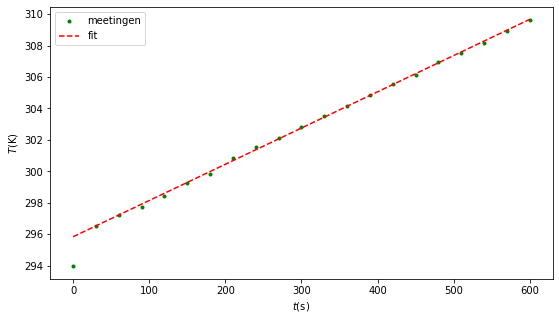

<Figure size 432x288 with 0 Axes>

In [91]:
#temp tegen de tijd plotten
plt.figure(figsize=(9,5))
plt.plot(t,T,'g.',label='meetingen') 
plt.plot(t_test,T_fit,'r--',label='fit')
plt.xlabel('$t \mathrm{(s)}$')
plt.ylabel('$T \mathrm{(K)}$')
plt.legend()
plt.show()
plt.savefig("../../Figures/water_temp_plot.png", dpi=450) #figuur opslaan


# Discussie en conclusie

We hebben het eerste datapunt op $t=0$ niet meegenomen in de analyse omdat deze erg afwijkt van het te verwachte lineare verband dat te zien is in de rest van de datapunten. De berekende waarde voor de warmtecapaciteit van water van 4179 J/KgK komt goed overeen met de bekende waarde van 4186 J/KgK. Wij zijn er vanuit gegaan dat er geen warmte verslies is naar de omgeving en dat de beker als geheel opwarmt tot dezelfde themperatuur van het water. Ook zijn we er vanuitgegaan dat er een constant vermogen wordt geleverd, maar in werkenlijkheid neemt de weerstand toe naarmaten de themperatuur steigt en wordt er minder vermogen geleverd. Er zit helaas een erg grote onzekerheid in de fit, ondankts dat hij goed lijkt te kloppen. Dit heeft waarschijnlijk te maken met de hoeveelheid aanpasingen die nodig waren aan de curve fit om tot een goed resultaat te komen.